In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('data.csv')

print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


In [11]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

In [12]:
df.isnull().sum()

Дата            0
Склад           0
Контрагент      0
Номенклатура    0
Количество      0
dtype: int64

In [13]:
df.describe()

,Склад,Количество
count,301355.000000,301355.000000
mean,2.900652,2.951559
std,1.352221,2.998154
min,1.000000,0.000000
25%,2.000000,1.000000
50%,3.000000,2.000000
75%,4.000000,4.000000
max,5.000000,200.000000


Проверяем формат столбцов

In [14]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [15]:
df.dtypes

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [16]:
daily_sales = df.groupby(df['Дата']).size().reset_index(name='sales_count')
print(daily_sales)

          Дата  sales_count
0   2018-01-04         1840
1   2018-01-05         1301
2   2018-01-06         1306
3   2018-01-07         1322
4   2018-01-09         1719
..         ...          ...
200 2018-08-26         1462
201 2018-08-28         1731
202 2018-08-29         1497
203 2018-08-30         1445
204 2018-08-31         1366

[205 rows x 2 columns]


Сгруппируйте данные по дате, посчитайте количество продаж

In [17]:
grouped_df = daily_sales.head()
grouped_df

,Дата,sales_count
0,2018-01-04,1840
1,2018-01-05,1301
2,2018-01-06,1306
3,2018-01-07,1322
4,2018-01-09,1719


Вывести несколько первых строк сгруппированных данных

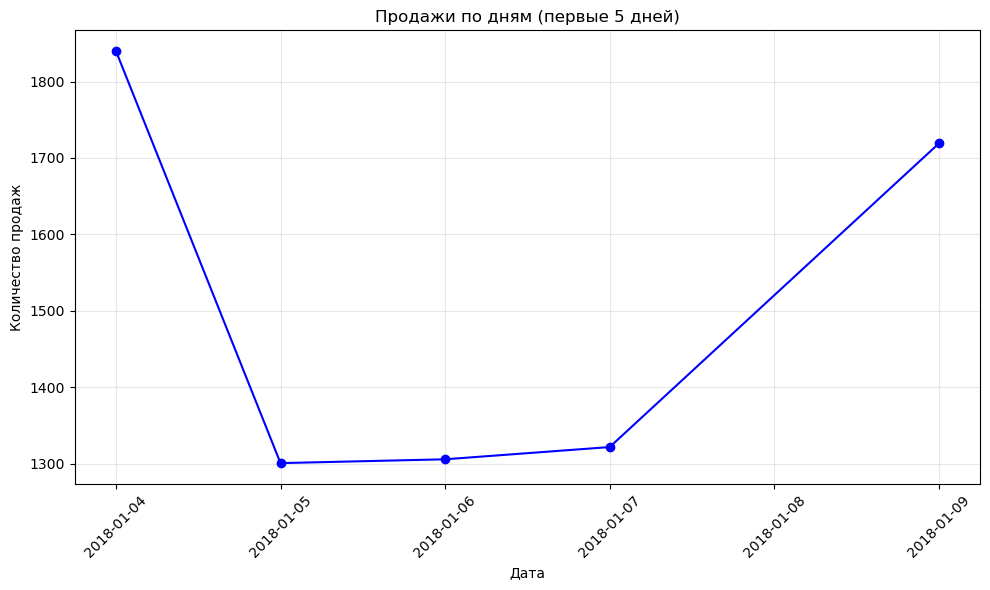

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(grouped_df['Дата'], grouped_df['sales_count'], marker='o', linestyle='-', color='blue')
plt.title('Продажи по дням (первые 5 дней)')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Нарисуйте график продаж у `grouped_df`

In [ ]:
На графике представлена линейная диаграмма, отображающая динамику продаж за первые 5 дней 
января 2018 года.
По оси X - даты (с 4 по 9 января 2018 года), по оси Y - количество продаж 
(от 1200 до 2000). Точки соединены линией, что позволяет увидеть тренд и изменения между днями.
Экстремальные точки
Максимум: 4 января (1840 продаж)
Минимум: 5 января (1301 продажа)
Форма графика
График похож на глубокую впадину или корыто:
Резкий спуск (4 - 5 января)
Плоское дно (5-7 января)
Резкий подъем (7 - 9 января)
Тренды
Дни 4-5: Обвал продаж (вероятно, окончание праздничного ажиотажа)
Дни 5-7: Плато (рынок нашёл равновесие)
Дни 7-9: Восстановление (возможно, начало рабочей недели или новая акция)


Опишите что вы видите на графике. Ваша задача - максимально описать график

In [19]:
max_sales_row = daily_sales.loc[daily_sales['sales_count'].idxmax()]
max_sales_row

Дата           2018-01-04 00:00:00
sales_count                   1840
Name: 0, dtype: object

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [20]:
sklad_number = 3
df_sklad = df[df['Склад'] == sklad_number].copy()

if df_sklad.empty:
    print(f"\nДля склада №{sklad_number} данные отсутствуют.")
else:
    print(f'\nДанные для склада №{sklad_number} загружены. Записей: {len(df_sklad)}')

df_sklad.loc[:, 'ДеньНедели'] = df_sklad['Дата'].dt.dayofweek

df_wednesday = df_sklad[df_sklad['ДеньНедели'] == 2].copy()

if df_wednesday.empty:
    print(f"\nДля склада №{sklad_number} нет данных за среды в указанном периоде.")
else:
    print(f"Записей за среды: {len(df_wednesday)}")
target_months = [6, 7, 8] # Июнь, Июль, Август
df_filtered = df_wednesday[df_wednesday['Дата'].dt.month.isin(target_months)].copy()
print(f"Записей за июнь-август: {len(df_filtered)}")
top_product = (
    df_filtered.groupby('Номенклатура')['Количество']
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

print(top_product)


Данные для склада №3 загружены. Записей: 68777
Записей за среды: 10942
Записей за июнь-август: 4345
Номенклатура
product_1    2267
Name: Количество, dtype: int64


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

,Местное время,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
05.03.2026 20:00,-0.5,730.7,763.2,0.6,96,"Ветер, дующий с юго-юго-востока",2,NaN,NaN,100%.,...,NaN,NaN,-1.1,0.5,12.0,NaN,NaN,NaN,NaN,NaN
05.03.2026 17:00,0.1,730.1,762.5,0.2,90,"Ветер, дующий с юга",2,NaN,NaN,100%.,...,NaN,4.0,-1.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
05.03.2026 14:00,-0.3,729.9,762.3,-0.3,96,"Ветер, дующий с юго-юго-востока",3,NaN,NaN,100%.,...,NaN,4.0,-0.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
05.03.2026 11:00,-0.8,730.2,762.7,-0.1,95,"Ветер, дующий с юга",3,NaN,NaN,100%.,...,NaN,4.0,-1.5,2.0,12.0,NaN,NaN,NaN,NaN,NaN
05.03.2026 08:00,-2.4,730.3,763.0,-0.5,96,"Ветер, дующий с юга",2,NaN,NaN,100%.,...,NaN,4.0,-3.0,2.0,12.0,NaN,NaN,Ровный слой сухого рассыпчатого снега покрывае...,42.0,NaN


C:\Users\adilkhan\AppData\Local\Temp\ipykernel_1060\3003999406.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_weather['Дата'] = pd.to_datetime(df_weather['Дата'], dayfirst=True, errors='coerce')



Среднедневная температура:
        Дата        T
0 2018-01-01  -9.4625
1 2018-01-02  -9.5125
2 2018-01-03 -11.4625
3 2018-01-04 -14.0750
4 2018-01-05 -16.8625


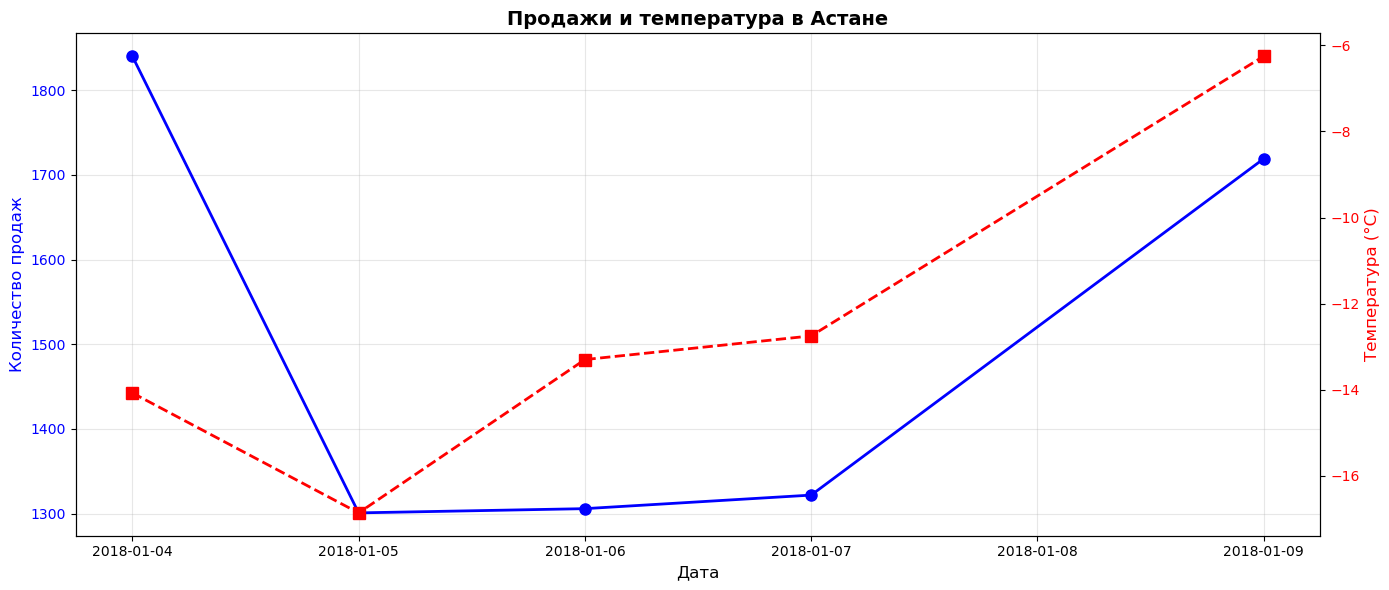

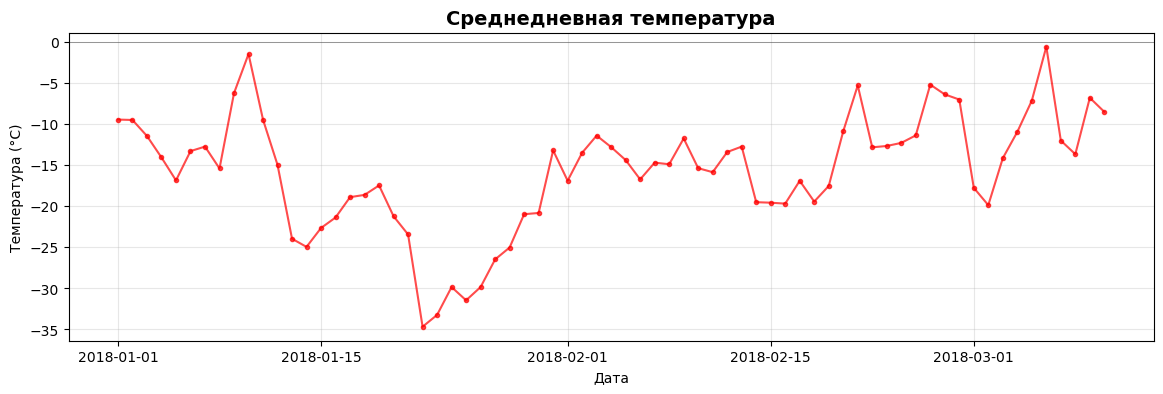


Статистика:
Макс температура: -0.6°C
Мин температура: -34.7°C
Средняя температура: -15.7°C


In [37]:
import os

grouped_df = pd.DataFrame({
    'Дата': pd.to_datetime(['2018-01-04', '2018-01-05', '2018-01-06', '2018-01-07', '2018-01-09']),
    'sales_count': [1840, 1301, 1306, 1322, 1719]
})


weather_file = 'pogoda_Ast.xls'

date_col = df_weather_raw.columns[0]

temp_col = None
for col in df_weather_raw.columns:
    if col == 'T' or 'темп' in str(col).lower() or 'temp' in str(col).lower():
        temp_col = col
        break

if temp_col is None:
    temp_col = df_weather_raw.columns[1]

df_weather = df_weather_raw[[date_col, temp_col]].copy()
df_weather.columns = ['Дата', 'T']

df_weather['Дата'] = pd.to_datetime(df_weather['Дата'], dayfirst=True, errors='coerce')

df_weather['T'] = pd.to_numeric(df_weather['T'], errors='coerce')

df_weather = df_weather.dropna()

daily_temp = df_weather.groupby(df_weather['Дата'].dt.date)['T'].mean().reset_index()
daily_temp['Дата'] = pd.to_datetime(daily_temp['Дата'])

print("\nСреднедневная температура:")
print(daily_temp.head())

merged_df = pd.merge(grouped_df, daily_temp, on='Дата', how='inner')

if not merged_df.empty:
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    ax1.set_xlabel('Дата', fontsize=12)
    ax1.set_ylabel('Количество продаж', color='blue', fontsize=12)
    ax1.plot(merged_df['Дата'], merged_df['sales_count'], 
            'bo-', linewidth=2, markersize=8, label='Продажи')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, alpha=0.3)
    
    ax2 = ax1.twinx()
    ax2.set_ylabel('Температура (°C)', color='red', fontsize=12)
    ax2.plot(merged_df['Дата'], merged_df['T'], 
            'rs--', linewidth=2, markersize=8, label='Температура')
    ax2.tick_params(axis='y', labelcolor='red')
    
    plt.title('Продажи и температура в Астане', fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.show()
    
    plt.figure(figsize=(14, 4))
    plt.plot(daily_temp['Дата'], daily_temp['T'], 
            'r.-', linewidth=1.5, alpha=0.7)
    plt.title('Среднедневная температура', fontsize=14, fontweight='bold')
    plt.xlabel('Дата')
    plt.ylabel('Температура (°C)')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
    plt.show()
    
    print(f"\nСтатистика:")
    print(f"Макс температура: {daily_temp['T'].max():.1f}°C")
    print(f"Мин температура: {daily_temp['T'].min():.1f}°C")
    print(f"Средняя температура: {daily_temp['T'].mean():.1f}°C")
else:
    print("\nНет общих дат!")
    print(f"Даты продаж: {grouped_df['Дата'].dt.date.tolist()}")
    print(f"Даты погоды: {daily_temp['Дата'].dt.date.tolist()}")
            
  

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [25]:
!pip install xlrd openpyxl

Всего замеров: 7.0
Минимальная температура: -3.6°C
Максимальная температура: 0.1°C
Средняя температура: -1.5°C
Медианная температура: -0.8°C
Стандартное отклонение: 1.51
        Дата  Средняя_температура
0 2026-03-05                 -1.5
      Дата  Средняя_температура
2026-03-05                 -1.5


        Дата  sales_count
0 2018-01-04         1840
1 2018-01-05         1301
2 2018-01-06         1306
3 2018-01-07         1322
4 2018-01-09         1719



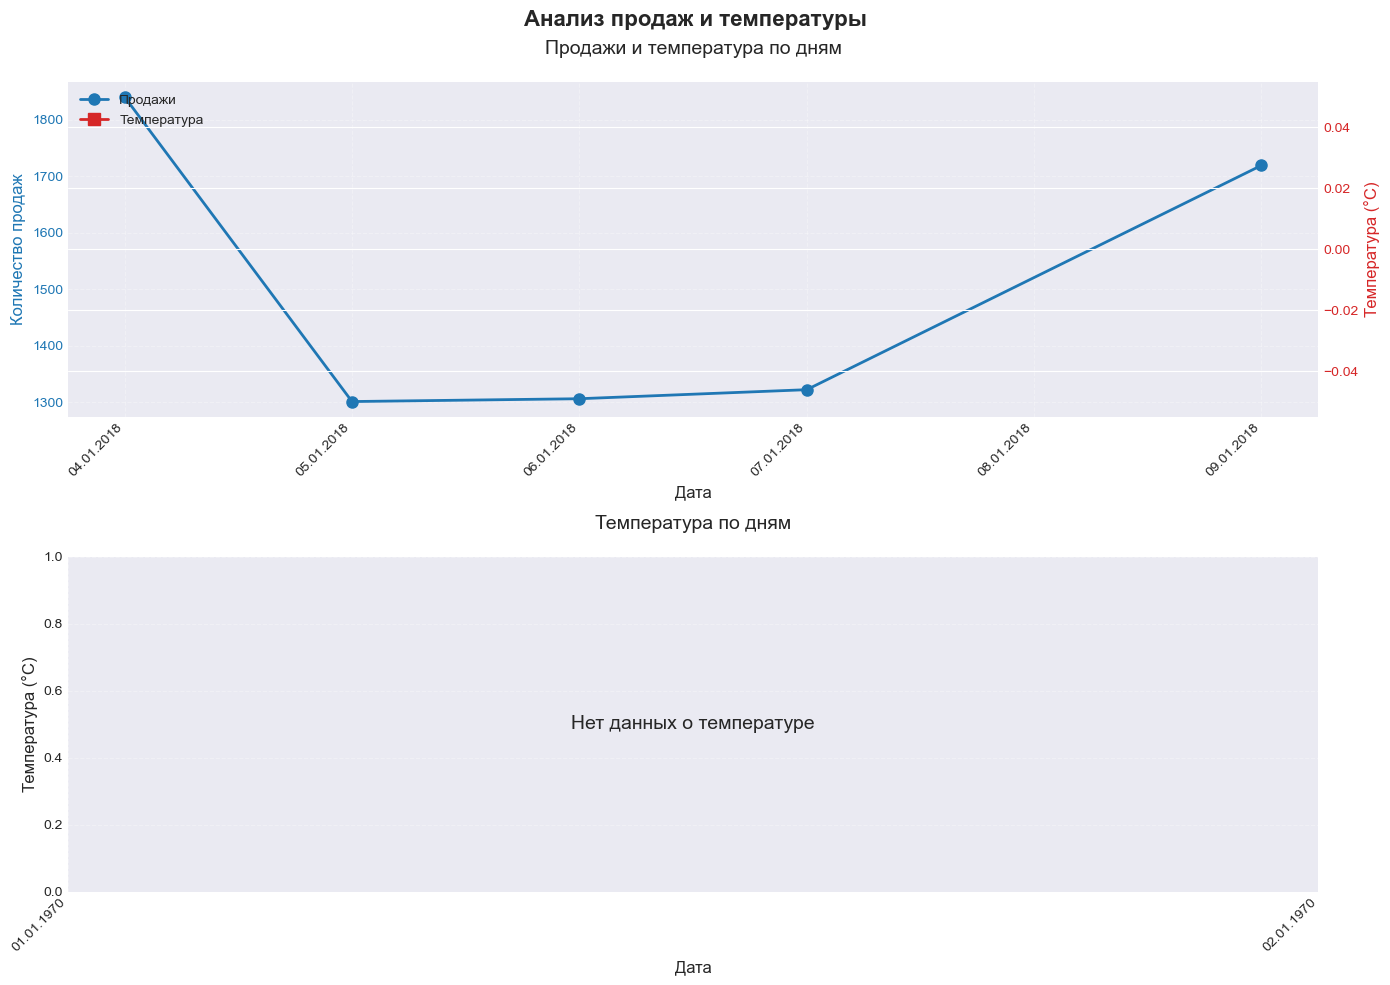

Период: с 04.01.2018 по 09.01.2018
Всего дней: 5
Дней с температурой: 0
